In [10]:
from scipy.io import mmread
from scipy.sparse import csr_matrix
from anndata import AnnData
import pandas as pd
import scanpy as sc


In [8]:
# Load matrix
matrix = mmread("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Tangram/data.mtx").T  # transpose if needed: cells x genes
matrix_csr = csr_matrix(matrix)

# Load metadata
obs = pd.read_csv("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Tangram/cell_metadata.csv", index_col=0)
var = pd.read_csv("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Tangram/gene_metadata.csv", index_col=0)

# Create AnnData object
adata = AnnData(X=matrix_csr, obs=obs, var=var)

# Load embeddings and store in .obsm
adata.obsm["X_pca"] = pd.read_csv("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Tangram/pca_embeddings.csv", index_col=0).values
adata.obsm["X_umap"] = pd.read_csv("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Tangram/umap_embeddings.csv", index_col=0).values

# Save AnnData to h5ad
adata.write("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Tangram/Goritz_all_scranseq_data_norm.h5ad")


/Users/anajul/opt/miniconda3/envs/banksy/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


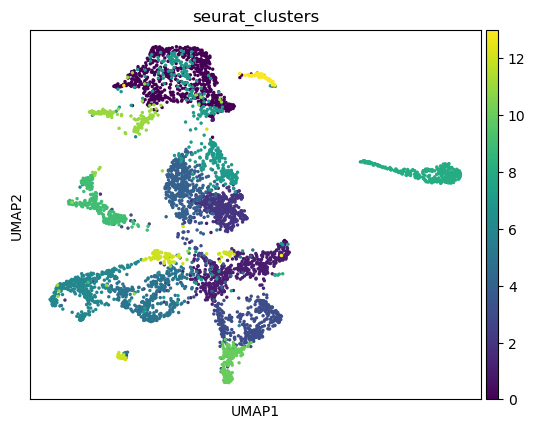

In [12]:
sc.pl.umap(adata, color = 'seurat_clusters', legend_loc = 'on data')